# CPWL time to accuracy, with an optional exact-SVD reference line
Time to accuracy (exp5), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): wall-clock time of the decomposition-free CPWL operator, evaluated through `sign_map.make_sgn_ns_until`, until every internal $\mathrm{msgn}$ call reaches a target $\varepsilon$, as a function of the degree $D$. With `svd_reference_line=True`, the exact SVD-based evaluation time of the same CPWL operator is also timed and drawn as a horizontal dashed line. Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU, and keep $\varepsilon$ above the rounding level of the dtype (about $10^{-6}$ in float32).

In [3]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_time_to_accuracy import CPWLTimeToAccuracyConfig, run_cpwl_time_to_accuracy
from experiments.time_to_accuracy import (  # same result layout as exp5
    time_to_accuracy_table, speedup_table, iterations_table, time_per_step_table, error_table,
)
%matplotlib inline

In [15]:
cfg = CPWLTimeToAccuracyConfig(
    sizes=[512], conds=[1e8], sigma_max=3.0, spectrum="log", degrees=[1, 10, 20],
    devices=["cuda"], dtypes=[torch.float64],
    profile="leaky_clip",                        # which of the fields below are read depends on the profile
    alpha=-0.5, beta=0.5, gamma=0.3, a=0.3, mu=0.5, knots=None, vals=None,
    eps=[1e-10],   # residual targets for every internal sign call, one run each
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    svd_reference_line=False,   # also time the SVD-based operator (column in the time table, speedup table)
    measure_error=True,         # also record the error reached vs the exact operator (one extra SVD per matrix)
    power_iters=10, power_margin=1.1, n_warmup=2, n_reps=5, cpu_threads=None, svd_driver=None, seed=0,
    verbose=True,  # progress only, results are in the tables below
)
res = run_cpwl_time_to_accuracy(cfg)

[1/1] n=512 cond=1e+08 (5 matrices)


## Time to reach $\varepsilon$ against the degree $D$, with the SVD line

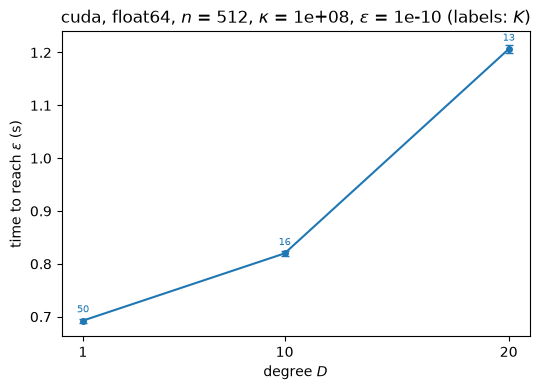

In [16]:
sel = dict(device="cuda", dtype=cfg.dtypes[0], n=cfg.sizes[0], cond=cfg.conds[0], eps=cfg.eps[0])
ax = plots.plot_time_vs_degree(res, **sel, show_svd=True)  # SVD line drawn if it was timed; False hides it
ax.figure.tight_layout()

In [7]:
args = (sel["device"], sel["dtype"], sel["cond"], sel["eps"])
time_to_accuracy_table(res, *args)
print()
if cfg.svd_reference_line:
    speedup_table(res, *args)
    print()
iterations_table(res, *args)
print()
time_per_step_table(res, *args)
if cfg.measure_error:
    print()
    error_table(res, *args)

time (s) to reach eps = 1e-06, median ± std over 20 matrices: CPWL operator (clip), cuda, float32, smin = 0.01
n    D=1              D=2              D=3              D=4              D=5              D=6              SVD             
256  0.0122 ± 0.0051  0.0107 ± 0.0036  0.0102 ± 0.0024  0.0104 ± 0.0029  0.0106 ± 0.0026  0.0113 ± 0.0028  0.0353 ± 0.00055

speedup over the SVD at eps = 1e-06 (median times): CPWL operator (clip), cuda, float32, smin = 0.01
n    D=1    D=2    D=3    D=4    D=5    D=6  
256  2.88x  3.30x  3.46x  3.40x  3.34x  3.12x

iterations K to reach eps = 1e-06, median (mean) over 20 matrices: CPWL operator (clip), cuda, float32, smin = 0.01
n    D=1         D=2         D=3       D=4       D=5       D=6     
256  16 (16.00)  11 (11.00)  9 (9.00)  8 (8.00)  7 (7.00)  7 (7.00)

time per step (ms) to reach eps = 1e-06, median time / median K: CPWL operator (clip), cuda, float32, smin = 0.01
n    D=1    D=2    D=3   D=4  D=5   D=6 
256  0.765  0.974  1.13  1.3  1.51  1.